In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neuralfoil as nf
#from pandas.core.indexes.api import default_index
#from requests.utils import get_netrc_auth
from scipy.optimize import bisect

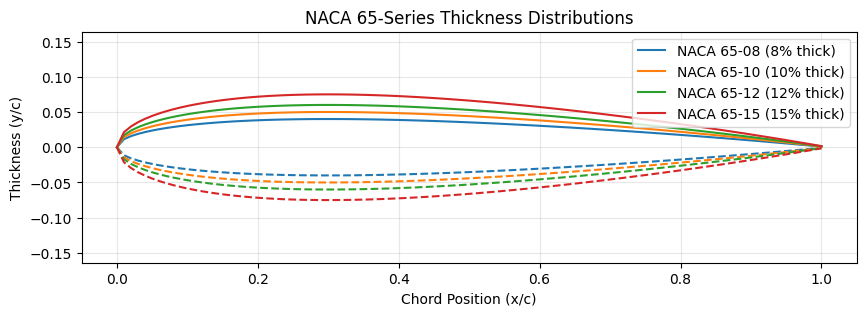

In [5]:
a0, a1, a2, a3, a4 = 0.2969, -0.1260, -0.3516, 0.2843, -0.1015

def naca65_thickness(x, thickness_ratio):
    """NACA 65-series thickness distribution"""
    return (thickness_ratio/0.2) * (a0*np.sqrt(x) + a1*x + a2*x**2 + a3*x**3 + a4*x**4)

# Example: Plot thickness distribution
x = np.linspace(0, 1, 100)
thicknesses = [0.08, 0.10, 0.12, 0.15]

plt.figure(figsize=(10, 3))
for t in thicknesses:
    yt = naca65_thickness(x, t)
    plt.plot(x, yt, label=f'NACA 65-{int(t*100):02d} ({t*100:.0f}% thick)')
    plt.plot(x, -yt, '--', color=plt.gca().lines[-1].get_color())

plt.xlabel('Chord Position (x/c)')
plt.ylabel('Thickness (y/c)')
plt.title('NACA 65-Series Thickness Distributions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [6]:
def circular_arc_camber(x, design_CL):
    """
    CORRECT Circular arc camber line
    design_CL: Target lift coefficient from radial equilibrium
    """
    # Convert design CL to maximum camber using thin airfoil theory
    g = design_CL / (2 * np.pi)
    h = g * 0.25  # Maximum camber height at mid-chord

    print(f"Design CL = {design_CL:.3f}")
    print(f"Maximum camber = {h*100:.2f}% of chord")

    # Symmetric airfoil for zero camber
    if h < 1e-6:
        return np.zeros_like(x), np.zeros_like(x)

    # Radius of circular arc
    R = (0.25 + h**2) / (2 * h)

    yc = np.sqrt(np.maximum(R**2 - (x - 0.5)**2, 0)) + h - R

    # Derivative (slope)
    with np.errstate(divide='ignore', invalid='ignore'):
        dyc_dx = (x - 0.5) / np.sqrt(np.maximum(R**2 - (x - 0.5)**2, 1e-12))
        dyc_dx = np.nan_to_num(dyc_dx, nan=0.0, posinf=0.0, neginf=0.0)

    # Calculate leading and trailing edge angles
    le_angle = np.rad2deg(np.arctan(dyc_dx[0]))  # Slope at x=0
    te_angle = np.rad2deg(np.arctan(dyc_dx[-1])) # Slope at x=1

    print(f"Leading edge angle = {le_angle:.2f}°")
    print(f"Trailing edge angle = {te_angle:.2f}°")
    print(f"Circular arc radius = {R:.3f} chord lengths")

    # Verification
    yc_mid = yc[len(yc)//2]  # Camber at mid-chord
    yc_le = yc[0]            # Camber at leading edge
    yc_te = yc[-1]           # Camber at trailing edge

    print(f"Verification: yc(0.5) = {yc_mid:.6f} (should be {h:.6f})")
    print(f"Verification: yc(0) = {yc_le:.6f} (should be 0)")
    print(f"Verification: yc(1) = {yc_te:.6f} (should be 0)")

    return yc, dyc_dx


Design CL = 0.500
Maximum camber = 1.99% of chord
Leading edge angle = -4.56°
Trailing edge angle = 4.56°
Circular arc radius = 6.293 chord lengths
Verification: yc(0.5) = 0.019892 (should be 0.019894)
Verification: yc(0) = 0.000000 (should be 0)
Verification: yc(1) = 0.000000 (should be 0)
Design CL = 1.000
Maximum camber = 3.98% of chord
Leading edge angle = -9.10°
Trailing edge angle = 9.10°
Circular arc radius = 3.161 chord lengths
Verification: yc(0.5) = 0.039785 (should be 0.039789)
Verification: yc(0) = 0.000000 (should be 0)
Verification: yc(1) = 0.000000 (should be 0)
Design CL = 1.500
Maximum camber = 5.97% of chord
Leading edge angle = -13.61°
Trailing edge angle = 13.61°
Circular arc radius = 2.124 chord lengths
Verification: yc(0.5) = 0.059677 (should be 0.059683)
Verification: yc(0) = 0.000000 (should be 0)
Verification: yc(1) = 0.000000 (should be 0)
Design CL = 2.000
Maximum camber = 7.96% of chord
Leading edge angle = -18.09°
Trailing edge angle = 18.09°
Circular arc r

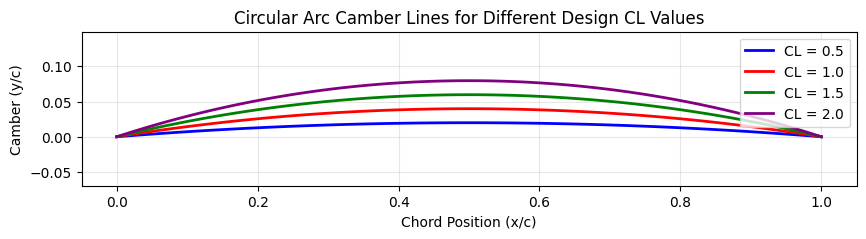

In [7]:
plt.figure(figsize=(10, 2))
design_CL_values = [0.5, 1.0, 1.5, 2.0]
colors = ['blue', 'red', 'green', 'purple']

for CL, color in zip(design_CL_values, colors):
    yc, _ = circular_arc_camber(x, CL)
    plt.plot(x, yc, color=color, linewidth=2, label=f'CL = {CL}')

plt.xlabel('Chord Position (x/c)')
plt.ylabel('Camber (y/c)')
plt.title('Circular Arc Camber Lines for Different Design CL Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [8]:
def generate_cambered_airfoil(design_CL, thickness_ratio=0.10, n_points=101):
    """
    Generate complete circular-cambered NACA 65-series airfoil
    """
    print(f"\n{'='*50}")
    print(f"GENERATING AIRFOIL: CL={design_CL:.3f}, thickness={thickness_ratio*100:.1f}%")
    print(f"{'='*50}")

    x = np.linspace(0, 1, n_points)

    # Get camber line and thickness
    yc, dyc_dx = circular_arc_camber(x, design_CL)
    yt = naca65_thickness(x, thickness_ratio)

    # Calculate upper and lower surfaces
    theta = np.arctan(dyc_dx)

    x_upper = x - yt * np.sin(theta)
    y_upper = yc + yt * np.cos(theta)

    x_lower = x + yt * np.sin(theta)
    y_lower = yc - yt * np.cos(theta)

    # Combine coordinates
    x_coords = np.concatenate([x_upper[::-1], x_lower[1:]])
    y_coords = np.concatenate([y_upper[::-1], y_lower[1:]])

    airfoil_data = {
        'x_coords': x_coords,
        'y_coords': y_coords,
        'camber_line': yc,
        'thickness_dist': yt,
        'design_CL': design_CL,
        'thickness_ratio': thickness_ratio,
        'name': f'NACA65-C{int(design_CL*100):03d}-{int(thickness_ratio*100):02d}'
    }

    return airfoil_data

def plot_airfoil(airfoil_data):
    """Plot the generated airfoil"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3))

    x = np.linspace(0, 1, len(airfoil_data['camber_line']))
    # Airfoil shape
    ax1.plot(airfoil_data['x_coords'], airfoil_data['y_coords'], 'b-', linewidth=2)
    ax1.plot(x, airfoil_data['camber_line'], 'r--', linewidth=1, label='Camber line')
    ax1.set_xlabel('Chord Position (x/c)')
    ax1.set_ylabel('Height (y/c)')
    ax1.set_title(f"Airfoil: {airfoil_data['name']}")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')

    # Camber and thickness
    ax2.plot(x, airfoil_data['camber_line'], 'r-', linewidth=2, label='Camber line')
    ax2.plot(x, airfoil_data['thickness_dist'], 'g-', linewidth=2, label='Thickness distribution')
    ax2.plot(x, -airfoil_data['thickness_dist'], 'g--', linewidth=1)
    ax2.set_xlabel('Chord Position (x/c)')
    ax2.set_ylabel('Height (y/c)')
    ax2.set_title('Camber and Thickness Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')

    plt.tight_layout()
    plt.show()

    return airfoil_data

In [9]:
airfoil = generate_cambered_airfoil(design_CL = 0.85, thickness_ratio=0.1)


GENERATING AIRFOIL: CL=0.850, thickness=10.0%
Design CL = 0.850
Maximum camber = 3.38% of chord
Leading edge angle = -7.74°
Trailing edge angle = 7.74°
Circular arc radius = 3.713 chord lengths
Verification: yc(0.5) = 0.033820 (should be 0.033820)
Verification: yc(0) = 0.000000 (should be 0)
Verification: yc(1) = 0.000000 (should be 0)


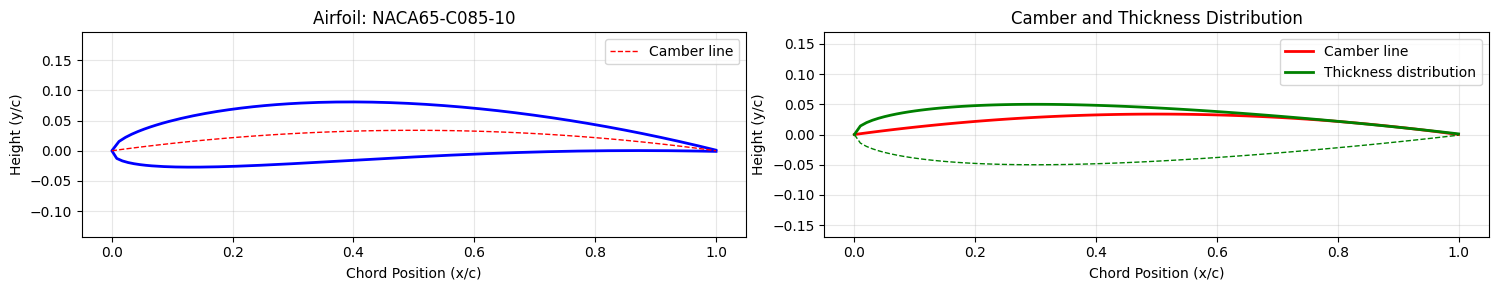

{'x_coords': array([0.9998586 , 0.98970807, 0.97956563, 0.96943113, 0.95930443,
        0.94918538, 0.93907385, 0.9289697 , 0.91887281, 0.90878304,
        0.89870028, 0.88862442, 0.87855532, 0.8684929 , 0.85843703,
        0.84838761, 0.83834454, 0.82830772, 0.81827705, 0.80825244,
        0.79823378, 0.788221  , 0.77821399, 0.76821266, 0.75821694,
        0.74822673, 0.73824195, 0.7282625 , 0.7182883 , 0.70831927,
        0.69835533, 0.68839637, 0.67844232, 0.66849309, 0.6585486 ,
        0.64860874, 0.63867343, 0.62874257, 0.61881608, 0.60889385,
        0.59897579, 0.58906178, 0.57915173, 0.56924554, 0.55934307,
        0.54944423, 0.53954889, 0.52965693, 0.51976822, 0.50988262,
        0.5       , 0.49012021, 0.48024311, 0.47036853, 0.46049631,
        0.45062628, 0.44075826, 0.43089207, 0.42102751, 0.41116437,
        0.40130244, 0.3914415 , 0.38158131, 0.37172162, 0.36186217,
        0.35200269, 0.34214288, 0.33228245, 0.32242107, 0.3125584 ,
        0.30269409, 0.29282775, 0.28

In [10]:
plot_airfoil(airfoil)

In [11]:
def analyze_airfoil_performance(airfoil_data, Re=500000):
    """Simpler version with proper coordinate formatting"""
    print(f"\nAnalyzing {airfoil_data['name']} at Re={Re:.0f}")

    alpha_range = np.linspace(-5, 15, 21)

    # Prepare coordinates: Nx2 array of (x, y) points
    coordinates = np.column_stack([airfoil_data['x_coords'], airfoil_data['y_coords']])

    # Analyze
    results = nf.get_aero_from_coordinates(
        coordinates,
        alpha_range,
        Re,
        model_size="large"
    )

    # Extract results safely
    CL_values = []
    CD_values = []

    for cl, cd in zip(results["CL"], results["CD"]):
        CL_values.append(cl.item() if hasattr(cl, 'item') else float(cl))
        CD_values.append(cd.item() if hasattr(cd, 'item') else float(cd))

    CL_values = np.array(CL_values)
    CD_values = np.array(CD_values)

    # Find actual design angle of attack
    design_alpha = np.interp(airfoil_data['design_CL'], CL_values, alpha_range)

    # Plot results
    plt.figure(figsize=(12, 12))

    plt.subplot(3, 1, 1)
    plt.plot(alpha_range, CL_values, 'b-', linewidth=2)
    plt.axhline(y=airfoil_data['design_CL'], color='r', linestyle='--',
                label=f'Target CL = {airfoil_data["design_CL"]:.2f}')
    plt.axvline(x=design_alpha, color='g', linestyle='--',
                label=f'Design α = {design_alpha:.1f}°')
    plt.xlabel('Angle of Attack α [°]')
    plt.ylabel('Lift Coefficient CL')
    plt.title(f'Lift Curve: {airfoil_data["name"]}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 2)
    plt.plot(alpha_range, CD_values, 'b-', linewidth=2)
    plt.axvline(x=design_alpha, color='g', linestyle='--',
                label=f'Design α = {design_alpha:.1f}°')
    plt.xlabel('Angle of Attack α [°]')
    plt.ylabel('Drag Coefficient CD')
    plt.title(f'Drag Curve: {airfoil_data["name"]}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(3, 1, 3)
    plt.plot(alpha_range, np.array(CL_values)/np.array(CD_values), 'g-', linewidth=2)
    plt.xlabel('Angle of Attack α [°]')
    plt.ylabel('Lift-to-Drag Ratio CL/CD')
    plt.title('Aerodynamic Efficiency')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Design angle of attack: {design_alpha:.2f}°")
    print(f"CL at design α: {np.interp(design_alpha, alpha_range, CL_values):.3f}")

    return design_alpha

In [12]:
import csv

def export_onshape_profile(profile, filename=None):
    """
    Export the aerodynamic profile to CSV file to use with Onshape (or any other CAD software).

    Input:
    - profile: Dictionary with nomralized coordinates abd name
    - filename: name for output file. If 'None', the filename is defined with the profile name. It has to have extension .csv
    """
    if filename is None:
        filename = profile.get('name', 'perfil_onshape') + '.csv'

    # Put the exension csv if it is missing
    if not filename.endswith('.csv'):
        filename += '.csv'

    x_coords = profile['x_coords']
    y_coords = profile['y_coords']

    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)

        for x, y in zip(x_coords, y_coords):
            writer.writerow([float(x), float(y), 0.0])

    print(f"✅ Profile '{profile.get('name', 'sin_nombre')}' exported to '{filename}'")
    print(f"   Total points: {len(x_coords)}")
    print(f"   X range: [{min(x_coords):.4f}, {max(x_coords):.4f}]")
    print(f"   Y range: [{min(y_coords):.4f}, {max(y_coords):.4f}]")


Analyzing NACA65-C085-10 at Re=500000


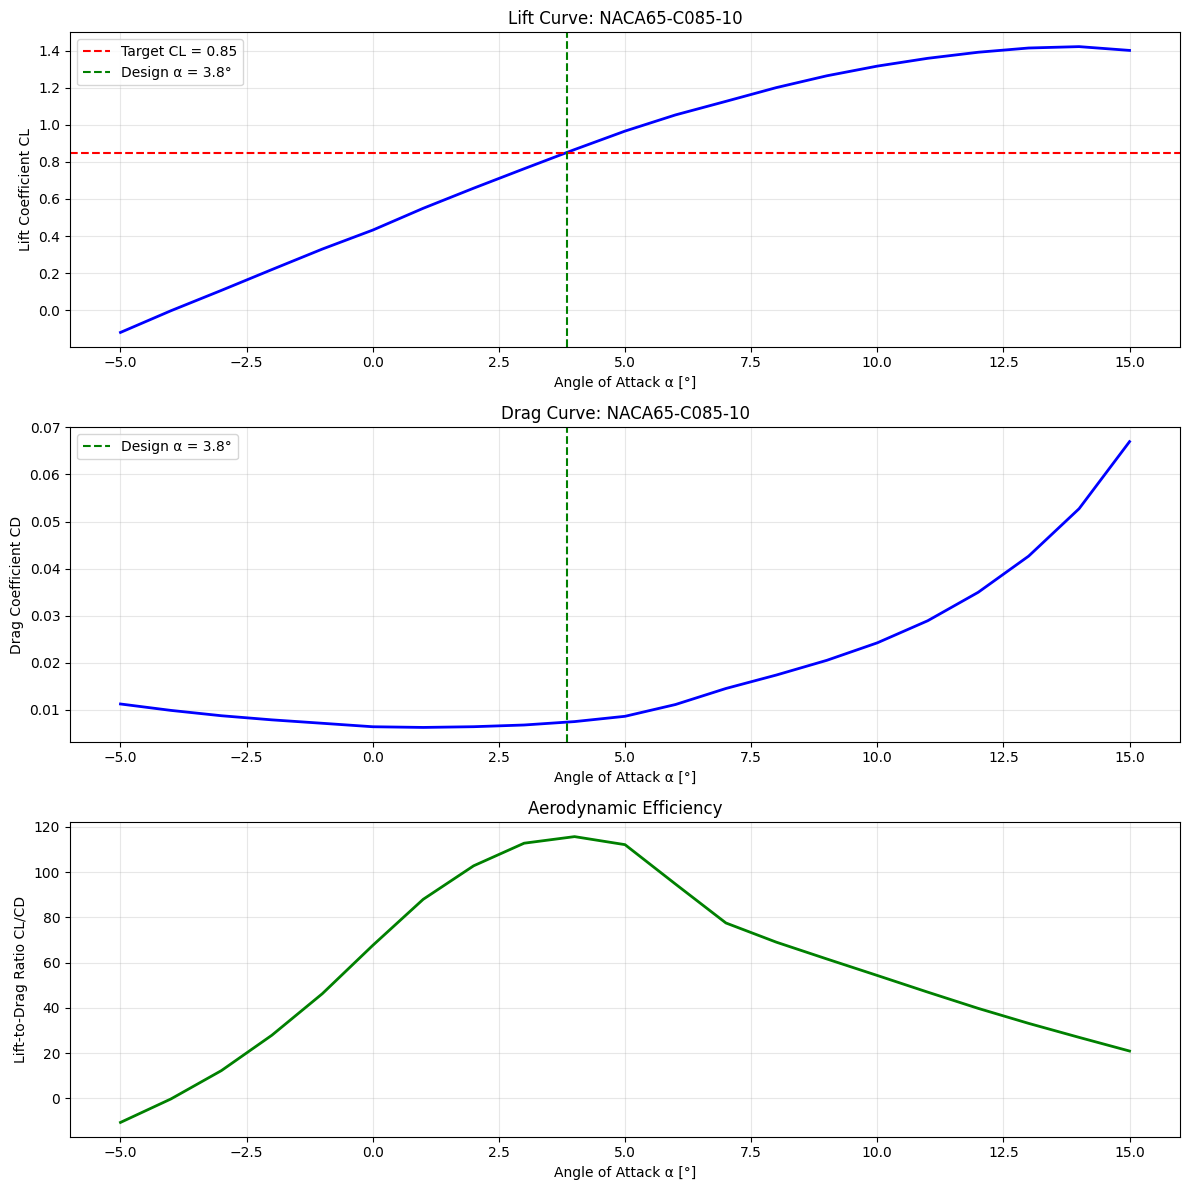

Design angle of attack: 3.84°
CL at design α: 0.850


In [13]:
analyze_airfoil = analyze_airfoil_performance(airfoil, Re=500000)

In [14]:
export_onshape_profile(airfoil)

✅ Profile 'NACA65-C085-10' exported to 'NACA65-C085-10.csv'
   Total points: 201
   X range: [0.0000, 1.0001]
   Y range: [-0.0271, 0.0808]


In [21]:
airfoil['x_coords']

array([0.9998586 , 0.98970807, 0.97956563, 0.96943113, 0.95930443,
       0.94918538, 0.93907385, 0.9289697 , 0.91887281, 0.90878304,
       0.89870028, 0.88862442, 0.87855532, 0.8684929 , 0.85843703,
       0.84838761, 0.83834454, 0.82830772, 0.81827705, 0.80825244,
       0.79823378, 0.788221  , 0.77821399, 0.76821266, 0.75821694,
       0.74822673, 0.73824195, 0.7282625 , 0.7182883 , 0.70831927,
       0.69835533, 0.68839637, 0.67844232, 0.66849309, 0.6585486 ,
       0.64860874, 0.63867343, 0.62874257, 0.61881608, 0.60889385,
       0.59897579, 0.58906178, 0.57915173, 0.56924554, 0.55934307,
       0.54944423, 0.53954889, 0.52965693, 0.51976822, 0.50988262,
       0.5       , 0.49012021, 0.48024311, 0.47036853, 0.46049631,
       0.45062628, 0.44075826, 0.43089207, 0.42102751, 0.41116437,
       0.40130244, 0.3914415 , 0.38158131, 0.37172162, 0.36186217,
       0.35200269, 0.34214288, 0.33228245, 0.32242107, 0.3125584 ,
       0.30269409, 0.29282775, 0.28295898, 0.27308735, 0.26321